# 2 Dimensional Heat Equation

$$ \frac{\partial u}{\partial t} = \sigma \Bigg( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \Bigg) $$ 

In this small analysis, we will asssume periodic Dirichlet Boundary Conditions:
$$ u(-1, y, t) = u(1, y, t) = u(x, -1, t) = u(x, 1, t) = 0 $$
with the following Initial Condition:
$$ z = \Big( 1 + \cos(\pi x) \Big) \Big( 1 + \cos(\pi y) \Big ) $$

### Importing Libraries

In [10]:
import math
import numpy as np
import matplotlib.pyplot as plt # type: ignore
import matplotlib.animation as ani # type: ignore
import functools
import matplotlib.animation as animation
from IPython.display import HTML
from numba import jit

### Functional conditions

In [11]:
sigma = 1
N = 50                          # number of points in the mesh
T = 1

dy = 2/(N -1)
dx = dy
dt = 3*dx**2/(16*sigma)

M = int(T/dt)                   # number of time steps
r = sigma*dt/(dx**2)

x = np.linspace(-1,1, N)
y = np.linspace(-1,1, N)
U = np.zeros((N,N,M))

Note: $ r = \sigma\frac{dt}{dx^2} \equiv \sigma\frac{ dt}{dy^2} $

In [12]:
if r > 0.25:
    raise ValueError("Stability condition violated! Reduce dt or increase dx.")

# Initial Condition

In [13]:
# Initial Condition function
def z0(x,y):
    Z0 = np.zeros((N,N))
    for i in range(len(x)):
        for j in range(len(y)):
            Z0[i,j] = (1 + np.cos(np.pi*x[i]))*(1 + np.cos(np.pi*y[j]))

    return(Z0)

# Implementation of the Fowrwad in Time Centered in Space Scheme (FTCS)

$$ \frac{U^{n+1}_{i,j} - U^n_{i,j}}{\Delta t} = \sigma \Bigg( \frac{U^n_{i+1, j} - 2 U^n_{i, j} + U^n_{i-1, j}}{\Delta x^2} + \frac{U^n_{i, j+1} - 2 U^n_{i, j} + U^n_{i, j-1}}{\Delta x^2} \Bigg) $$

$$ \implies U^{n+1}_{i,j} = U^n_{i,j} + r\Big(U^n_{i+1, j} - 2 U^n_{i, j} + U^n_{i-1, j} \Big) + r \Big(U^n_{i, j+1} - 2 U^n_{i, j} + U^n_{i, j-1} \Big) $$

In [14]:
# Applying the initial condition
U[:,:,0] = z0(x,y)

#Implementation of the FTCS
for n in range(M-1):
    for j in range(N-1):
        for k in range(N-1):
            U[j,k,n+1] = U[j,k,n]+ r*U[j+1,k, n] + -2*r*U[j,k,n] + r*U[j-1,k, n] \
                            + r*U[j,k+1, n] + -2*r*U[j,k,n] + r*U[j,k-1, n]

KeyboardInterrupt: 

### Plotting Isolines

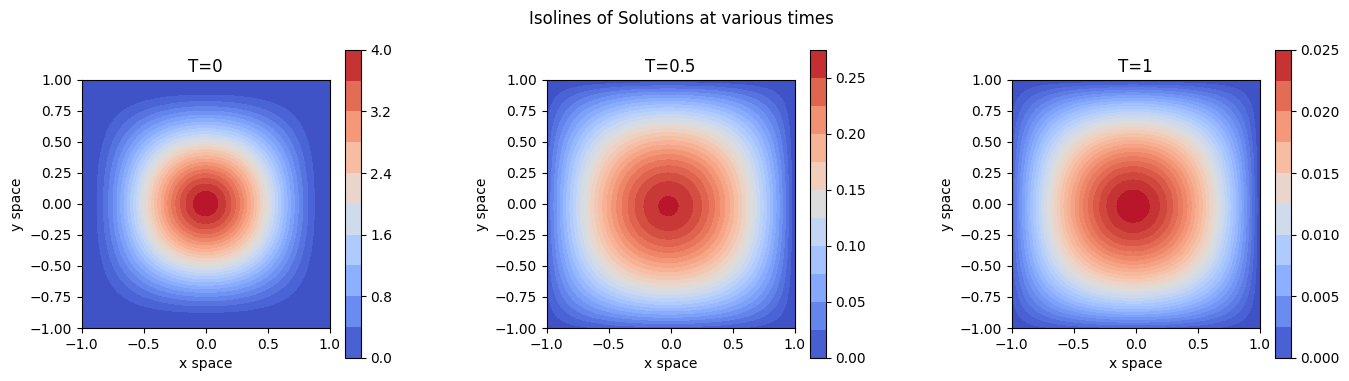

In [ ]:
# Create Iso-Plots
fig, ax = plt.subplots(1,3,figsize=(16, 4))
fig.suptitle("Isolines of Solutions at various times")
fig.subplots_adjust(wspace=.5)

z = [U[:,:,0], U[:,:,int((M-1)/2)], U[:,:,M-1]]

for i in range(3):
    contour = ax[i].contourf(x,y, z[i], levels=10, cmap='coolwarm')
    ax[i].contourf(x,y, z[i], levels=30, cmap='coolwarm')
    ax[i].set_xlabel("x space")
    ax[i].set_ylabel("y space")
    ax[i].set_aspect('equal')
    fig.colorbar(contour, ax=ax[i]) 

ax[0].set_title("T=0")
ax[1].set_title("T=0.5")
ax[2].set_title("T=1")


plt.show()

### Plotting 3d raised Profiles

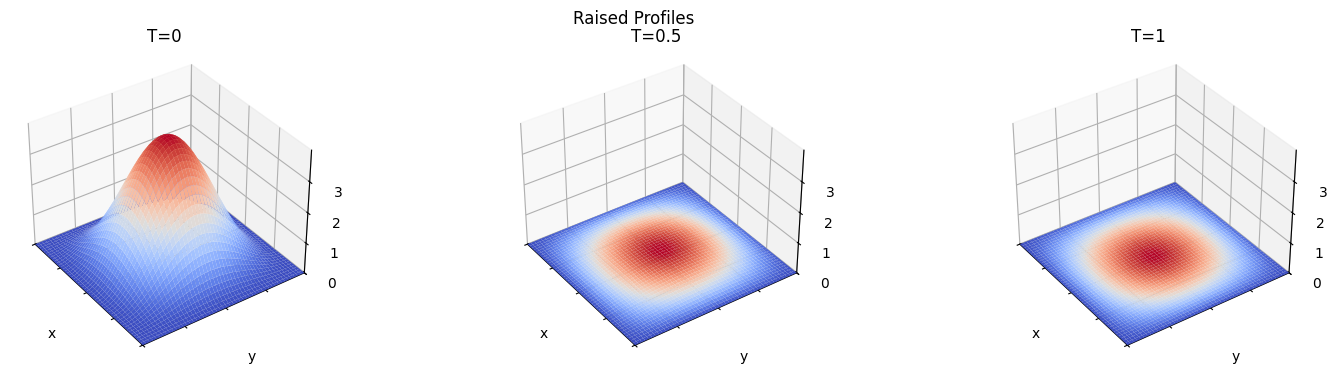

In [ ]:
x_mesh, y_mesh = np.meshgrid(x,y)
fig, ax = plt.subplots(1,3,figsize=(18, 4), subplot_kw={"projection": "3d"})
fig.suptitle("Raised Profiles")

z = [U[:,:,0], U[:,:,int((M-1)/2)], U[:,:,M-1]]

for i in range(3):
    ax[i].set_xlabel('x')
    ax[i].set_xlim3d([x.min(), x.max()])
    ax[i].set_xticklabels([])
    ax[i].set_ylabel('y')
    ax[i].set_ylim3d([y.min(), y.max()])
    ax[i].set_yticklabels([])
    #ax[i].set_zticklabels([])
    ax[i].set_zlim3d([z[0].max(), z[0].min()])
    ax[i].view_init(elev=-145, azim=-145)
    ax[i].plot_surface(x_mesh,y_mesh, z[i], cmap='coolwarm',)

ax[0].set_title("T=0")
ax[1].set_title("T=0.5")
ax[2].set_title("T=1")

plt.show()

# 3d Animation

In [ ]:
# Frame Function to create 3d animation
def update(frame, ax, surfaces, x_mesh, y_mesh, zdata, anim=False):
    if surfaces and surfaces[0]:
        surfaces[0].remove()
        
    surfaces.clear()
    surf = ax.plot_surface(x_mesh, y_mesh, zdata[:,:,frame], 
                           cmap='coolwarm', linewidth=0, antialiased=False, animated=anim,
                            vmin=zdata.min(), vmax=zdata.max())
    
    surfaces.append(surf)
    return surfaces

KeyboardInterrupt: 

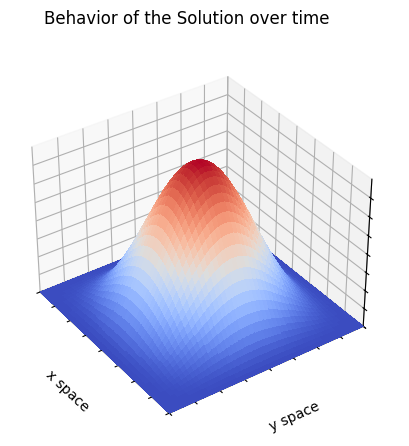

In [ ]:
# Animation of the 3d solution
time = np.zeros(M+1)
for i in range(M+1):
  time[i] = i*dt

frames = 1/dx
x_mesh, y_mesh = np.meshgrid(x, y)

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
fig.suptitle("Behavior of the Solution over time")

ax.set_xlabel('x space')
ax.set_xlim([x.min(), x.max()])
ax.set_xticklabels([])

ax.set_ylabel('y space')
ax.set_ylim([y.min(), y.max()])
ax.set_yticklabels([])

ax.set_zlabel('z')
ax.set_zlim([U[:,:,0].max(), U[:,:,0].min()])
ax.set_zticklabels([])

ax.view_init(elev=-145, azim=-145)

N = len(time)

surf = []

update_anim = functools.partial(update, ax=ax, surfaces=surf, 
                                x_mesh=x_mesh, y_mesh=y_mesh, zdata=U, anim=True)

ani = animation.FuncAnimation(fig, update_anim, M, interval=frames, blit=False)
ani.save('2d_heat.gif', writer="pillow")
HTML(ani.to_jshtml())
plt.show()